# VN Portfolio Screener

Pipeline: Fetch giá → Lọc thanh khoản → CAGR/Sharpe → Correlation clustering → 6 mã output


## Cell 1 — Cài thư viện


In [1]:
!pip install vnstock openpyxl pandas numpy scipy scikit-learn matplotlib seaborn -q



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Import


In [2]:
import time, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)


## Cell 3 — Universe cổ phiếu


In [3]:
SECTOR_STOCKS = {
    'cong nghiep & logistics': [
        'GMD','HAH','VSC','PVT','VOS','VTO','STG','SFI','GSP','MHC',
        'HVN','VJC','SCS','AST','SKG','VTP','TOT','ASG','TMS',
        'GEX','GEE','REE','VEA','CAV','TLG','GDT','CTR',
        'BCM','KBC','PHR','SZL','LHG','SZC','TIP','D2D','GVR','IDC',
    ],
    'Tai chinh ngan hang': [
        'VCB','BID','CTG','TCB','VPB','MBB','HDB','LPB','ACB',
        'STB','SHB','VIB','TPB','SSB','EIB','MSB','OCB','EVF',
        'KLB','VAB','TCX',
        'SSI','VCK','VPX','VIX','VCI','VND','FTS','DSE','BSI',
        'ORS','CTS','VDS','DSC','AGR',
    ],
    'Tieu dung': [
        'VNM','MSN','SBT','HAG','KDC','VHC','BAF','DBC','VCF',
        'ANV','PAN','MCM','FMC','IDI','CLC','NSC','OGC','ANT',
        'LSS','ABT','CMX','ACL','DAT','TSC','SSC','AFX','LAF',
        'HSL','AAM','MCH','VMD','LIX','SGT','FIT','DLG','SAB',
        'BHN','NAF','SMB',
    ],
    'Xay dung ha tang': [
        'CTD','HBC','VCG','FCN','LCG','HAS','HU1','HU3','HUB',
        'C47','C32','LM8','MCG','CIG','DC4','ACC','HID','CEE',
        'NHA','MDG','CDC','CII','HHV','DPG','PC1','CTI','HTI',
        'BCE','FCM','HVH','SC5','HPG','HSG','NKG','TVN','POM',
        'SMC','TIS','VGS','HMC','VIS','HT1','HVX','DXV','CVT',
        'DHA','VGC','BMP','NNC','LBM','PTB','NAV','NTP','EVG',
    ],
    'Cong nghe': ['MWG','FRT','PET','FPT','VGT','HIG','PMG'],
}

ALL_SYMBOLS, SYMBOL_TO_SECTOR = [], {}
seen = set()
for sector, syms in SECTOR_STOCKS.items():
    for s in syms:
        if s not in seen:
            seen.add(s)
            ALL_SYMBOLS.append(s)
            SYMBOL_TO_SECTOR[s] = sector

print(f'{len(ALL_SYMBOLS)} ma, {len(SECTOR_STOCKS)} nganh')
for sec, syms in SECTOR_STOCKS.items():
    print(f'  {sec}: {len(syms)} ma')


172 ma, 5 nganh
  cong nghiep & logistics: 37 ma
  Tai chinh ngan hang: 35 ma
  Tieu dung: 39 ma
  Xay dung ha tang: 54 ma
  Cong nghe: 7 ma


## Cell 4 — Cấu hình


In [4]:
FETCH_START   = '2023-06-01'
FETCH_END     = '2025-12-31'
PRICE_SCALE   = 1e6
DELAY_SEC     = 3
SOURCES       = ['VCI', 'TCBS']
BATCH_SIZE    = 18

SECTOR_MIN_LIQ = {
    'Tai chinh ngan hang': 50.0,
    'Tieu dung':            3.0,
    'cong nghiep & logistics': 3.0,
    'Cong nghe':            2.0,
    'Xay dung ha tang':     2.0,
    '_default':             1.5,
}

MIN_WEEKS       = 10
N_CLUSTERS      = 6
MAX_PER_CLUSTER = 1
RISK_FREE       = 0.0273               # annual, chi de tham khao
RF_WEEKLY       = (1 + RISK_FREE) ** (1/52) - 1   # dung cho Sharpe
MIN_MEAN_R      = RF_WEEKLY            # loai ma co mean return <= rf
WEEKS_PER_YEAR  = 52

print('Config OK')
print(f'  RF_WEEKLY = {RF_WEEKLY*100:.6f}%/tuan  ({RISK_FREE*100:.2f}%/nam)')
print(f'  MIN_MEAN_R = {MIN_MEAN_R*100:.6f}%/tuan  (loai ma mean <= rf)')


Config OK
  RF_WEEKLY = 0.051810%/tuan  (2.73%/nam)
  MIN_MEAN_R = 0.051810%/tuan  (loai ma mean <= rf)


## Cell 5 — Fetch giá


In [5]:
from vnstock import Quote

class RateLimiter:
    def __init__(self, calls=18, window=62):
        self.calls, self.window = calls, window
        self.ts = collections.deque()

    def wait(self):
        now = time.time()
        while self.ts and now - self.ts[0] > self.window:
            self.ts.popleft()
        if len(self.ts) >= self.calls:
            sleep = self.window - (now - self.ts[0]) + 1
            if sleep > 0:
                print(f'  rate limit: nghi {int(sleep)}s')
                time.sleep(sleep)
        self.ts.append(time.time())


def fetch_price(sym, start, end, rl):
    for src in SOURCES:
        try:
            rl.wait()
            time.sleep(DELAY_SEC)
            df = Quote(source=src, symbol=sym,
                       random_agent=False, show_log=False
                       ).history(start=start, end=end, interval='1D')
            if df is None or df.empty:
                continue

            df.columns = [c.lower().strip() for c in df.columns]
            date_col  = next((c for c in ['time','date','tradingdate'] if c in df.columns), None)
            close_col = next((c for c in ['close','closeprice','adjclose'] if c in df.columns), None)
            vol_col   = next((c for c in ['volume','tradingvolume','vol'] if c in df.columns), None)

            if date_col:
                df[date_col] = pd.to_datetime(df[date_col])
                df = df.set_index(date_col).sort_index()
            elif isinstance(df.index, pd.DatetimeIndex):
                df = df.sort_index()
            else:
                continue

            if close_col is None:
                continue

            out = df[[close_col]].rename(columns={close_col: 'close'})
            out['close']  = pd.to_numeric(out['close'], errors='coerce')
            out['volume'] = pd.to_numeric(df[vol_col], errors='coerce') if vol_col else np.nan
            out = out.dropna(subset=['close'])
            out = out[out['close'] > 0]

            if len(out) >= MIN_WEEKS:
                return out
        except Exception as e:
            err = str(e).lower()
            if '403' in err or 'forbidden' in err: time.sleep(15)
            if '429' in err or 'rate' in err:      time.sleep(30)
    return None


price_data, errors = {}, {}
rl = RateLimiter(BATCH_SIZE, 62)

for i, sym in enumerate(ALL_SYMBOLS, 1):
    if i > 1 and (i-1) % BATCH_SIZE == 0:
        print('  batch pause 62s...')
        time.sleep(62)

    print(f'[{i:03d}/{len(ALL_SYMBOLS)}] {sym:<6} ...', end=' ', flush=True)
    df = fetch_price(sym, FETCH_START, FETCH_END, rl)
    if df is None:
        errors[sym] = 'skip'
        print('SKIP')
    else:
        price_data[sym] = df
        liq = float((df['close'] * df['volume'].fillna(0)).mean() / PRICE_SCALE)
        print(f'{len(df)} ngay  liq={liq:.1f}ty')

print(f'\nOK={len(price_data)}  SKIP={len(errors)}')
if errors:
    print(f'Skip: {sorted(errors)}')


[001/172] GMD    ... 677 ngay  liq=94.0ty
[002/172] HAH    ... 677 ngay  liq=99.9ty
[003/172] VSC    ... 677 ngay  liq=103.7ty
[004/172] PVT    ... 677 ngay  liq=61.0ty
[005/172] VOS    ... 677 ngay  liq=31.8ty
[006/172] VTO    ... 677 ngay  liq=6.3ty
[007/172] STG    ... 677 ngay  liq=0.3ty
[008/172] SFI    ... 677 ngay  liq=0.2ty
[009/172] GSP    ... 677 ngay  liq=2.3ty
[010/172] MHC    ... 677 ngay  liq=2.8ty
[011/172] HVN    ... 677 ngay  liq=42.7ty
[012/172] VJC    ... 677 ngay  liq=131.3ty
[013/172] SCS    ... 677 ngay  liq=13.4ty
[014/172] AST    ... 677 ngay  liq=1.0ty
[015/172] SKG    ... 677 ngay  liq=6.1ty
[016/172] VTP    ... 677 ngay  liq=78.2ty
[017/172] TOT    ... 677 ngay  liq=0.1ty
[018/172] ASG    ... 677 ngay  liq=0.1ty
  batch pause 62s...
[019/172] TMS    ... 677 ngay  liq=0.3ty
[020/172] GEX    ... 677 ngay  liq=360.6ty
[021/172] GEE    ... 677 ngay  liq=36.0ty
[022/172] REE    ... 677 ngay  liq=41.4ty
[023/172] VEA    ... 677 ngay  liq=23.1ty
[024/172] CAV    ...

## Cell 6 — Lọc thanh khoản


In [6]:
liq_passed, liq_values = [], {}

for sym, df in price_data.items():
    # dung 26 tuan (~6 thang) gan nhat — phan anh kha nang giao dich hien tai
    recent = df.last('182D')
    liq = float((recent['close'] * recent['volume'].fillna(0)).mean() / PRICE_SCALE)
    sec = SYMBOL_TO_SECTOR.get(sym, '_default')
    thr = SECTOR_MIN_LIQ.get(sec, SECTOR_MIN_LIQ['_default'])
    liq_values[sym] = liq
    if liq >= thr:
        liq_passed.append(sym)
    else:
        print(f'  loai {sym:<6}  {liq:.2f}ty < {thr:.1f}ty')

print(f'\npass={len(liq_passed)}  loai={len(price_data)-len(liq_passed)}')
for sec, syms in SECTOR_STOCKS.items():
    n_in = [s for s in syms if s in price_data]
    n_ok = [s for s in n_in if s in liq_passed]
    print(f'  {sec:<35} {len(n_ok)}/{len(n_in)}')


  loai STG     0.02ty < 3.0ty
  loai SFI     0.08ty < 3.0ty
  loai GSP     0.96ty < 3.0ty
  loai AST     1.02ty < 3.0ty
  loai SKG     2.31ty < 3.0ty
  loai TOT     0.14ty < 3.0ty
  loai ASG     0.05ty < 3.0ty
  loai TMS     0.11ty < 3.0ty
  loai CAV     0.69ty < 3.0ty
  loai GDT     0.77ty < 3.0ty
  loai SZL     0.46ty < 3.0ty
  loai TIP     2.50ty < 3.0ty
  loai KLB     9.36ty < 50.0ty
  loai VAB     14.87ty < 50.0ty
  loai DSE     23.91ty < 50.0ty
  loai DSC     3.08ty < 50.0ty
  loai AGR     25.77ty < 50.0ty
  loai VCF     0.41ty < 3.0ty
  loai MCM     1.01ty < 3.0ty
  loai CLC     0.18ty < 3.0ty
  loai NSC     0.21ty < 3.0ty
  loai ANT     1.71ty < 3.0ty
  loai ABT     0.81ty < 3.0ty
  loai CMX     2.04ty < 3.0ty
  loai ACL     0.45ty < 3.0ty
  loai DAT     0.11ty < 3.0ty
  loai TSC     2.37ty < 3.0ty
  loai SSC     0.02ty < 3.0ty
  loai AFX     1.84ty < 3.0ty
  loai LAF     0.12ty < 3.0ty
  loai AAM     0.05ty < 3.0ty
  loai VMD     0.33ty < 3.0ty
  loai LIX     1.63ty < 3.0ty
  

## Cell 7 — Sharpe


In [7]:
weekly_close, stats = {}, {}

for sym in liq_passed:
    w  = price_data[sym]['close'].resample('W-FRI').last().dropna()
    wr = w.pct_change().dropna()

    if len(wr) < MIN_WEEKS:
        continue

    # Sharpe theo cong thuc thay: (R_bar - R_F) / sigma
    # tat ca giu don vi TUAN — khong annualize
    mean_r = float(wr.mean())
    std    = float(wr.std(ddof=1))
    sharpe = (mean_r - RF_WEEKLY) / std if std > 0 else 0.0

    weekly_close[sym] = w
    stats[sym] = {
        'mean_r': mean_r,
        'std':    std,
        'sharpe': sharpe,
        'n':      len(wr),
        'liq':    liq_values.get(sym, 0),
        'sector': SYMBOL_TO_SECTOR.get(sym, ''),
    }

# loc ma co mean return <= rf (excess return am)
ret_passed = [s for s in stats if stats[s]['mean_r'] > MIN_MEAN_R]
ret_failed = [s for s in stats if stats[s]['mean_r'] <= MIN_MEAN_R]

print(f'Mean_r > RF_weekly ({MIN_MEAN_R*100:.6f}%):  pass={len(ret_passed)}  loai={len(ret_failed)}')
if ret_failed:
    for s in sorted(ret_failed, key=lambda x: stats[x]['mean_r']):
        print(f'  {s:<6}  mean_r={stats[s]["mean_r"]*100:.4f}%  Sharpe={stats[s]["sharpe"]:.3f}')

df_stats = (pd.DataFrame(stats).T.loc[ret_passed]
            .astype({'mean_r':float,'std':float,'sharpe':float,'n':int,'liq':float})
            .sort_values('sharpe', ascending=False))
display(df_stats[['sector','mean_r','std','sharpe','liq','n']])
print(f'\n{len(ret_passed)} ma vao clustering')


Mean_r > RF_weekly (0.051810%):  pass=99  loai=10
  OGC     mean_r=-0.3992%  Sharpe=-0.082
  SAB     mean_r=-0.2269%  Sharpe=-0.086
  POM     mean_r=-0.1792%  Sharpe=-0.029
  SSB     mean_r=-0.1329%  Sharpe=-0.055
  IDI     mean_r=-0.1278%  Sharpe=-0.037
  KDC     mean_r=-0.0907%  Sharpe=-0.061
  BCM     mean_r=-0.0813%  Sharpe=-0.035
  HBC     mean_r=-0.0447%  Sharpe=-0.017
  FMC     mean_r=0.0059%  Sharpe=-0.015
  VNM     mean_r=0.0510%  Sharpe=-0.000


,sector,mean_r,std,sharpe,liq,n
GEE,cong nghiep & logistics,0.0214,0.0760,0.2747,121.2402,141
MCH,Tieu dung,0.0140,0.0500,0.2704,59.0705,141
NAF,Tieu dung,0.0106,0.0386,0.2624,19.2718,140
LPB,Tai chinh ngan hang,0.0125,0.0459,0.2607,137.2474,140
NNC,Xay dung ha tang,0.0105,0.0394,0.2531,3.1042,140
...,...,...,...,...,...,...
VGT,Cong nghe,0.0020,0.0502,0.0289,14.3035,140
LCG,Xay dung ha tang,0.0010,0.0419,0.0118,46.9121,140
TCX,Tai chinh ngan hang,0.0010,0.0445,0.0105,112.9145,10
MSN,Tieu dung,0.0010,0.0424,0.0103,718.6108,140



99 ma vao clustering


## Cell 8 — Correlation + Clustering


Bo 1 ma thieu data (< 72 tuan): ['TCX']
Vao clustering: 98 ma  (144 tuan)

6 clusters:
  C1: 14 ma  best=LPB(0.26)  [BID, CTG, TCB, VPB, MBB, LPB, ACB, STB...]
  C2: 21 ma  best=FRT(0.19)  [GMD, SCS, VTP, CTR, PHR, LHG, SZC, D2D...]
  C3: 17 ma  best=BMP(0.20)  [PVT, VOS, VTO, HVN, REE, VEA, SBT, PAN...]
  C4: 7 ma  best=GEE(0.27)  [GEE, TLG, MCH, HID, HTI, HVH, NNC]
  C5: 3 ma  best=NAF(0.26)  [MHC, HSL, NAF]
  C6: 36 ma  best=HDB(0.22)  [HAH, VSC, VJC, GEX, KBC, VCB, HDB, SHB...]


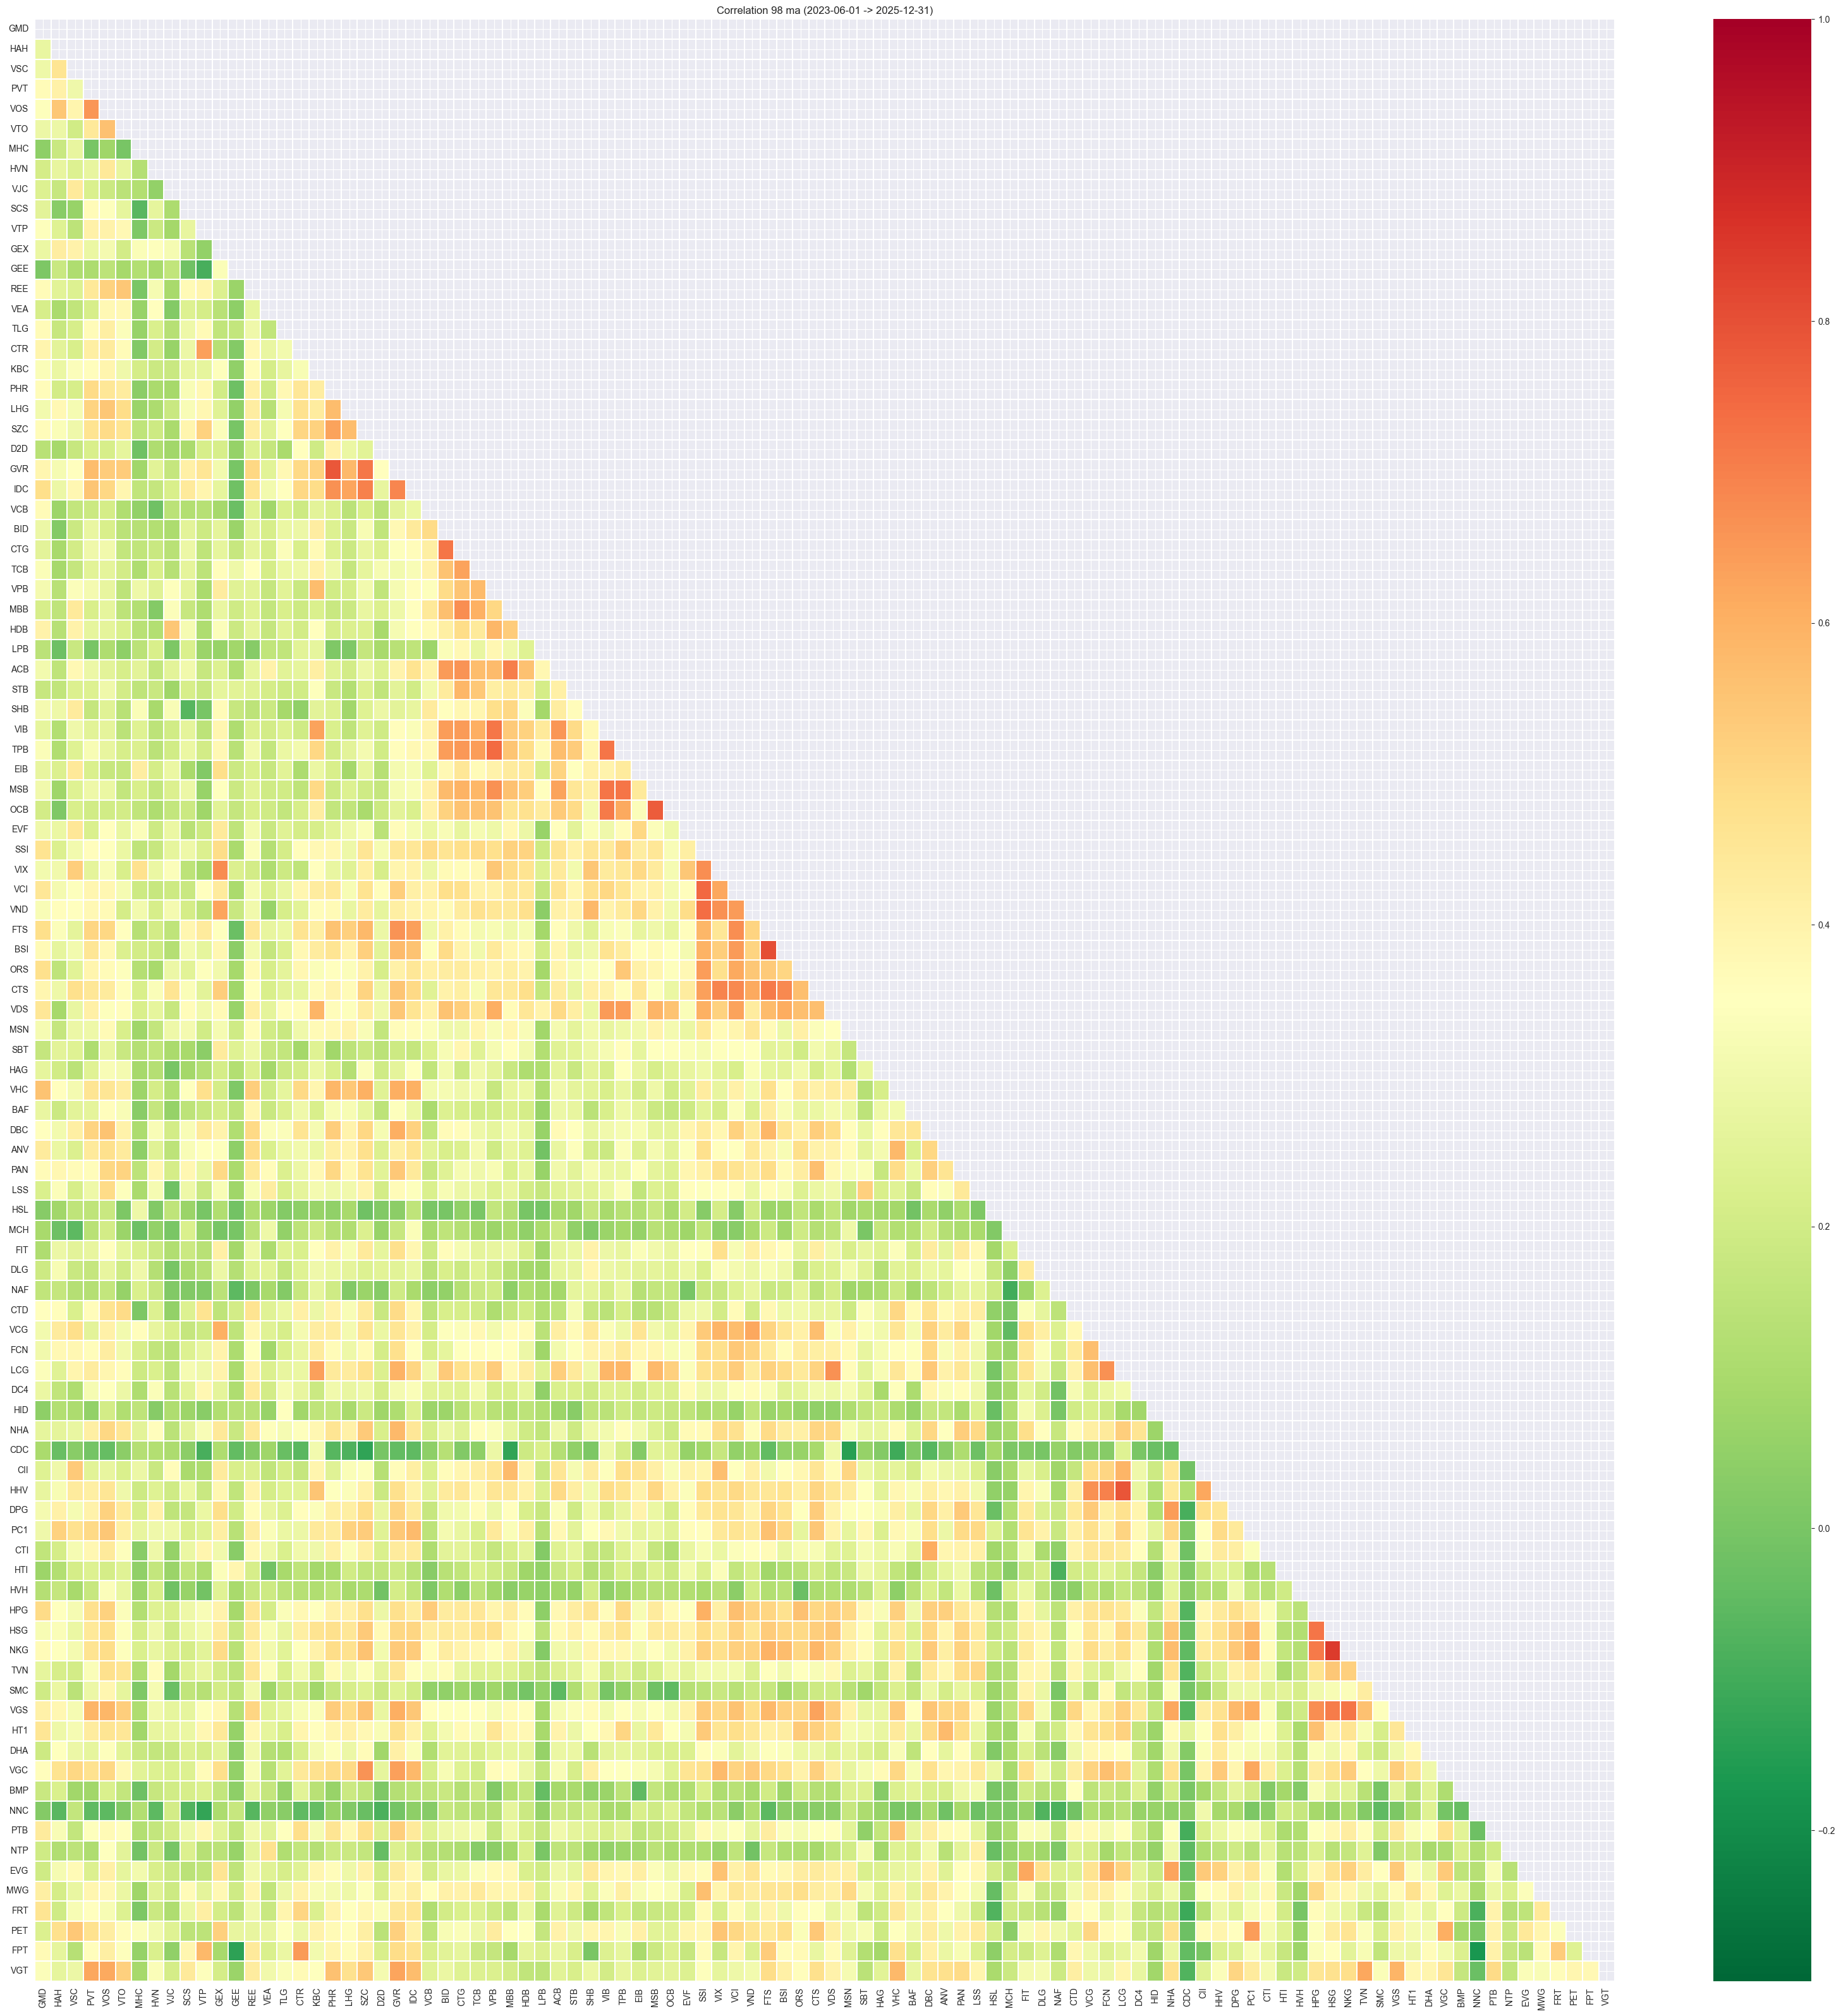

In [8]:
df_weekly  = pd.DataFrame({s: weekly_close[s] for s in ret_passed}).sort_index()
df_returns = df_weekly.pct_change().dropna(how='all')
n_weeks    = len(df_returns)

min_valid  = max(8, int(n_weeks * 0.5))
valid_syms = [c for c in df_returns.columns if df_returns[c].notna().sum() >= min_valid]
dropped    = sorted(set(ret_passed) - set(valid_syms))
if dropped:
    print(f'Bo {len(dropped)} ma thieu data (< {min_valid} tuan): {dropped}')

df_ret      = df_returns[valid_syms].dropna(how='all')
corr_matrix = df_ret.corr(method='pearson', min_periods=max(8, min_valid//2))

good_syms = [s for s in corr_matrix.columns if corr_matrix[s].notna().mean() >= 0.3]
dropped2  = sorted(set(valid_syms) - set(good_syms))
if dropped2:
    print(f'Bo {len(dropped2)} ma nan corr: {dropped2}')

print(f'Vao clustering: {len(good_syms)} ma  ({n_weeks} tuan)')

corr_matrix = corr_matrix.loc[good_syms, good_syms]

# impute NaN bang median cua tam giac tren (khong gom diagonal)
n_nan = corr_matrix.isna().sum().sum()
if n_nan > 0:
    upper_vals = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
    med = float(np.nanmedian(upper_vals))
    corr_matrix = corr_matrix.fillna(med)
    np.fill_diagonal(corr_matrix.values, 1.0)
    print(f'Impute {n_nan} NaN bang median off-diagonal = {med:.3f}')

# dam bao doi xung
arr = corr_matrix.values.astype(float)
arr = (arr + arr.T) / 2
np.fill_diagonal(arr, 1.0)
corr_matrix = pd.DataFrame(arr, index=good_syms, columns=good_syms)

N       = len(good_syms)
n_clust = min(N_CLUSTERS, N)
dist    = np.clip(1 - corr_matrix.values, 0, 2)
np.fill_diagonal(dist, 0)
Z       = linkage(squareform(dist, checks=False), method='ward')
labels  = fcluster(Z, t=n_clust, criterion='maxclust')

cluster_dict = collections.defaultdict(list)
for sym, lbl in zip(good_syms, labels):
    cluster_dict[int(lbl)].append(sym)

print(f'\n{n_clust} clusters:')
for cid in sorted(cluster_dict):
    syms_in = cluster_dict[cid]
    best    = max(syms_in, key=lambda s: stats[s]['sharpe'])
    print(f'  C{cid}: {len(syms_in)} ma  best={best}({stats[best]["sharpe"]:.2f})'
          f'  [{", ".join(syms_in[:8])}{"..." if len(syms_in)>8 else ""}]')

N_show = len(good_syms)
fig, ax = plt.subplots(figsize=(max(10, N_show//3), max(8, N_show//3)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            annot=(N_show <= 30), fmt='.2f', linewidths=0.3, ax=ax)
ax.set_title(f'Correlation {N_show} ma ({FETCH_START} -> {FETCH_END})')
plt.tight_layout()
plt.show()


## Cell 9 — Chọn đại diện mỗi cluster


In [9]:
selected_syms = []

for cid in sorted(cluster_dict):
    ranked = sorted(cluster_dict[cid], key=lambda s: stats[s]['sharpe'], reverse=True)
    picked = ranked[:MAX_PER_CLUSTER]
    others = ranked[MAX_PER_CLUSTER:]
    selected_syms.extend(picked)

    def fmt(s): return f"{s}({stats[s]['sharpe']:.2f})"
    rej = '  |  bo: ' + ', '.join(fmt(s) for s in others) if others else ''
    print(f'C{cid}: {", ".join(fmt(s) for s in picked)}{rej}')

print(f'\n{len(selected_syms)} ma duoc chon: {selected_syms}')


C1: LPB(0.26)  |  bo: TCB(0.19), MBB(0.18), STB(0.15), CTG(0.15), ACB(0.13), CDC(0.12), VDS(0.11), VPB(0.10), VIB(0.09), MSB(0.09), OCB(0.08), TPB(0.07), BID(0.04)
C2: FRT(0.19)  |  bo: VTP(0.18), D2D(0.16), MWG(0.15), FPT(0.14), FTS(0.11), GVR(0.10), PHR(0.09), BSI(0.09), ANV(0.08), GMD(0.08), PTB(0.08), SZC(0.07), CTR(0.07), LHG(0.07), IDC(0.05), ORS(0.05), HT1(0.04), VHC(0.04), MSN(0.01), SCS(0.00)
C3: BMP(0.20)  |  bo: NTP(0.14), HVN(0.13), SBT(0.13), DPG(0.12), CTD(0.11), DC4(0.10), PAN(0.09), VTO(0.09), REE(0.08), NHA(0.07), TVN(0.07), VEA(0.07), PVT(0.06), VOS(0.06), LSS(0.03), VGT(0.03)
C4: GEE(0.27)  |  bo: MCH(0.27), NNC(0.25), HTI(0.16), HVH(0.13), HID(0.10), TLG(0.06)
C5: NAF(0.26)  |  bo: MHC(0.15), HSL(0.06)
C6: HDB(0.22)  |  bo: HAH(0.20), BAF(0.19), VIX(0.18), GEX(0.18), DHA(0.17), SHB(0.17), CTS(0.14), DBC(0.13), HAG(0.13), VGS(0.13), SSI(0.13), VJC(0.12), EVG(0.12), HPG(0.11), CTI(0.11), VCG(0.09), CII(0.09), EVF(0.08), VND(0.08), VCI(0.08), VSC(0.07), PET(0.07), KBC(

## Cell 10 — Kiểm tra chất lượng


corr TB toan bo  : 0.284
corr TB bo chon  : 0.116  (nen thap hon)
corr max bo chon : 0.283


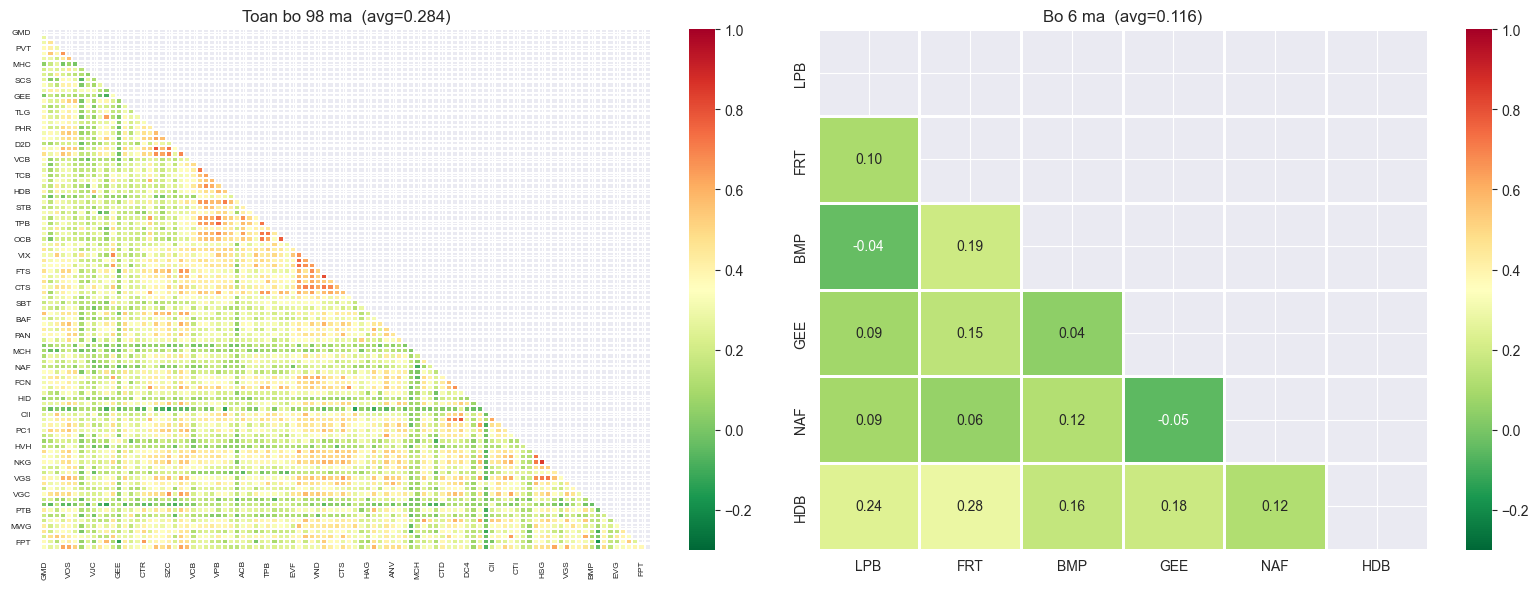

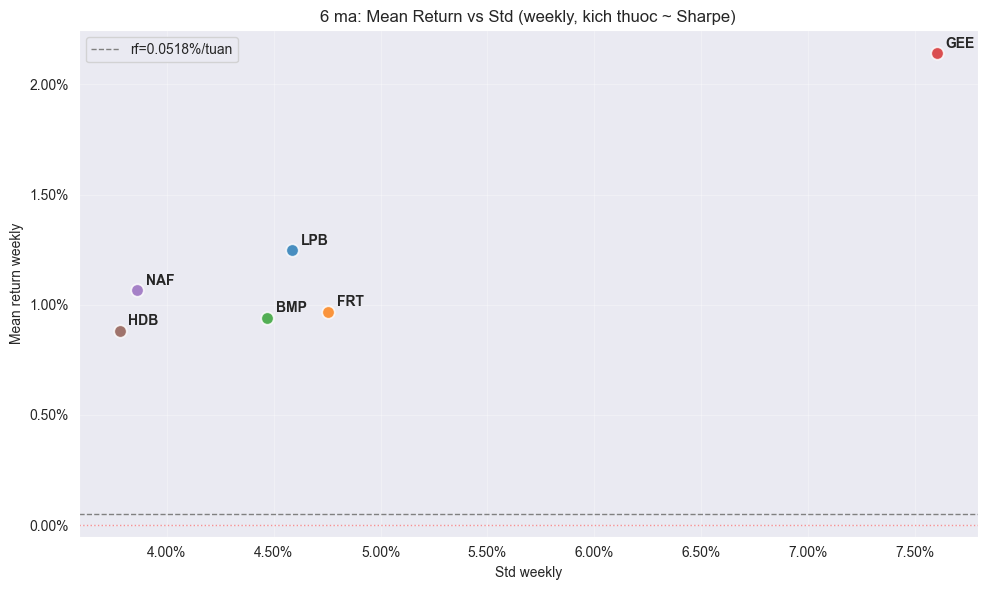

In [10]:
corr_sel  = corr_matrix.loc[selected_syms, selected_syms]
upper_all = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)).stack()
upper_sel = corr_sel.where(np.triu(np.ones_like(corr_sel, dtype=bool), k=1)).stack()

print(f'corr TB toan bo  : {upper_all.mean():.3f}')
print(f'corr TB bo chon  : {upper_sel.mean():.3f}  (nen thap hon)')
print(f'corr max bo chon : {upper_sel.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask_all = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask_all, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            ax=axes[0], annot=False, linewidths=0.2)
axes[0].set_title(f'Toan bo {N} ma  (avg={upper_all.mean():.3f})')
axes[0].tick_params(labelsize=6)

mask_sel = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(corr_sel, mask=mask_sel, cmap='RdYlGn_r', vmin=-0.3, vmax=1.0,
            ax=axes[1], annot=True, fmt='.2f', linewidths=0.8)
axes[1].set_title(f'Bo {len(selected_syms)} ma  (avg={upper_sel.mean():.3f})')

plt.tight_layout()
plt.show()

# scatter CAGR vs Vol
fig, ax = plt.subplots(figsize=(10, 6))
for sym in selected_syms:
    st = stats[sym]
    ax.scatter(st['std'], st['mean_r'], s=max(80, st['sharpe']*250),
               alpha=0.8, edgecolors='white', linewidths=1.2, zorder=3)
    ax.annotate(sym, (st['std'], st['mean_r']),
                textcoords='offset points', xytext=(6, 4), fontsize=10, fontweight='bold')

ax.axhline(RF_WEEKLY, color='gray', linestyle='--', linewidth=1, label=f'rf={RF_WEEKLY*100:.4f}%/tuan')
ax.axhline(0, color='red', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Std weekly')
ax.set_ylabel('Mean return weekly')
ax.set_title('6 ma: Mean Return vs Std (weekly, kich thuoc ~ Sharpe)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.2f}%'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.2f}%'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 11 — Output cuối


In [11]:
df_out = (pd.DataFrame(stats).T.loc[selected_syms]
          .astype({'mean_r':float,'std':float,'sharpe':float,'liq':float,'n':int})
          .sort_values('sharpe', ascending=False))
df_out['cluster'] = [next(c for c, ss in cluster_dict.items() if s in ss) for s in df_out.index]

disp = df_out[['cluster','sector','mean_r','std','sharpe','liq']].copy()
disp.columns = ['Cluster','Nganh','Mean_r (tuan)','Std (tuan)','Sharpe','Liq(ty)']
disp['Mean_r (tuan)'] = disp['Mean_r (tuan)'].map('{:+.4%}'.format)
disp['Std (tuan)']    = disp['Std (tuan)'].map('{:.4%}'.format)
display(disp)

print('\nFINAL_SYMBOLS = [')
for s in selected_syms:
    st = stats[s]
    print(f"    '{s}',   # {st['sector']}  mean_r={st['mean_r']*100:+.4f}%/tuan  Sharpe={st['sharpe']:.3f}")
print(']')


,Cluster,Nganh,Mean_r (tuan),Std (tuan),Sharpe,Liq(ty)
GEE,4,cong nghiep & logistics,+2.1404%,7.6026%,0.2747,121.2402
NAF,5,Tieu dung,+1.0650%,3.8614%,0.2624,19.2718
LPB,1,Tai chinh ngan hang,+1.2478%,4.5871%,0.2607,137.2474
HDB,6,Tai chinh ngan hang,+0.8822%,3.7788%,0.2198,468.3202
BMP,3,Xay dung ha tang,+0.9398%,4.4704%,0.1986,21.8194
FRT,2,Cong nghe,+0.9682%,4.7556%,0.1927,82.8231



FINAL_SYMBOLS = [
    'LPB',   # Tai chinh ngan hang  mean_r=+1.2478%/tuan  Sharpe=0.261
    'FRT',   # Cong nghe  mean_r=+0.9682%/tuan  Sharpe=0.193
    'BMP',   # Xay dung ha tang  mean_r=+0.9398%/tuan  Sharpe=0.199
    'GEE',   # cong nghiep & logistics  mean_r=+2.1404%/tuan  Sharpe=0.275
    'NAF',   # Tieu dung  mean_r=+1.0650%/tuan  Sharpe=0.262
    'HDB',   # Tai chinh ngan hang  mean_r=+0.8822%/tuan  Sharpe=0.220
]


## Cell 12 — Xuất Excel


In [12]:
OUTPUT_FILE = 'vn_6stock_screener.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df_out.reset_index().rename(columns={'index':'symbol'}) \
          .to_excel(writer, sheet_name='Selected', index=False)

    (pd.DataFrame(stats).T
     .astype({'mean_r':float,'std':float,'sharpe':float,'liq':float,'n':int})
     .reset_index().rename(columns={'index':'symbol'})
     .sort_values('sharpe', ascending=False)
     .to_excel(writer, sheet_name='All Qualified', index=False))

    rows = [{'cluster':c,'symbol':s,'selected':s in selected_syms,
              'sector':SYMBOL_TO_SECTOR.get(s,''),
              **{k: stats.get(s,{}).get(k) for k in ['mean_r','sharpe','liq']}}
            for c, syms in cluster_dict.items() for s in syms]
    (pd.DataFrame(rows).sort_values(['cluster','sharpe'],ascending=[True,False])
     .to_excel(writer, sheet_name='Clusters', index=False))

    corr_sel.to_excel(writer, sheet_name='Corr (6 stocks)')

    if errors:
        pd.DataFrame({'symbol':list(errors)}).to_excel(writer, sheet_name='Skipped', index=False)

    for ws in writer.sheets.values():
        for col in ws.columns:
            w = max((len(str(c.value or '')) for c in col[:40]), default=8)
            ws.column_dimensions[col[0].column_letter].width = min(w+3, 35)

print(f'Da luu: {OUTPUT_FILE}')


Da luu: vn_6stock_screener.xlsx
